# Cross-modal geometry: full-data description, then held-out trials
Run `compare_subspace.py` first. Conditions are equally averaged after trial averaging. The all-data fit is explicitly in-sample (repeat -1); it is followed by five folds with disjoint test trials, fixed cohort and matching, and overlapping training sets. There is no tuning or test A/B.

Temporal rows are time points. Spatial rows are electrode/source correspondences. Generalization concerns new trials at the same participants and locations.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'compare_subspace.py').exists() and (ROOT / 'iEEGvsMEG' / 'compare_subspace.py').exists():
    ROOT = ROOT / 'iEEGvsMEG'
sys.path.insert(0, str(ROOT))
from compare_subspace import load_results, plot_results

MEG_KIND = 'paired_coverage'  # full_average, full_concatenated, coverage_average, paired_coverage, random_control
OUTPUT_DIR = ROOT / 'out' / 'compare_subspace' / MEG_KIND
DISPLAY_K = 3 

## Run the analysis
```bash
python -u compare_subspace.py --root /path/to/iEEGvsMEG \
  --meg-kind paired_coverage --models separate_pca plssvd joint_pca \
  --dimensions 1 2 3 5 10 --n-splits 5 --block-scaling equal_variance \
  --ridge-alpha 0.01 --output-dir /path/to/new_geometry_results
```
Use a new directory if results already exist. Whole-modality scaling remains configurable; ridge is fixed, and all requested cluster counts are reported.


In [2]:
config, tables = load_results(OUTPUT_DIR)
if config.get('schema_version', 1) < 2:
    raise ValueError('Run the updated analysis into a new directory: these outputs use the old split design.')
display(pd.Series(config, name='Run configuration'))
# Full-data fit first: descriptive scores, not testing or an upper bound.
for name in ('overlap', 'alignment', 'clusters'):
    print(f'All-data description: {name}')
    display(tables[name].query("partition == 'in_sample' and k == @DISPLAY_K"))
plot_results(OUTPUT_DIR, k=DISPLAY_K, show=False)


schema_version                                                             2
condition_mode                                                       average
full_data_repeat                                                          -1
cache_dir                  /users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/...
meg_kind                                                     paired_coverage
models                                     [separate_pca, plssvd, joint_pca]
dimensions                                                  [1, 2, 3, 5, 10]
repeats                                                                    5
seed                                                                    2026
block_scaling                                                 equal_variance
split_unit                                                             trial
cluster_counts                                               [2, 3, 4, 5, 6]
ridge_grid                                                            [0.01]

All-data description: overlap


,analysis,model,repeat,k,space,partition,overlap,rank_a,rank_b,angles_deg
4,in_sample,separate_pca,-1,3,temporal_scores,in_sample,0.497875,3,3,"[20.554225252267276, 39.717168128104184, 80.86..."
5,in_sample,separate_pca,-1,3,spatial_patterns,in_sample,0.000673,3,3,"[87.58667270203442, 89.10682891368272, 89.9253..."
14,in_sample,plssvd,-1,3,temporal_scores,in_sample,0.840166,3,3,"[19.828313269312204, 23.317040473691847, 27.11..."
15,in_sample,plssvd,-1,3,spatial_patterns,in_sample,0.000754,3,3,"[87.40545651838076, 89.16148552074222, 89.9962..."
24,in_sample,joint_pca,-1,3,temporal_scores,in_sample,0.778586,3,3,"[16.59807348456142, 25.617536957686006, 38.980..."
25,in_sample,joint_pca,-1,3,spatial_patterns,in_sample,0.000754,3,3,"[87.52475604831415, 88.86063854780483, 89.9544..."


All-data description: alignment


,analysis,model,repeat,k,space,direction,complexity,partition,alpha,nrmse,q2
32,in_sample,separate_pca,-1,3,temporal_scores,ieeg_to_meg,identity,in_sample,0.00,0.791827,0.373010
33,in_sample,separate_pca,-1,3,temporal_scores,ieeg_to_meg,orthogonal,in_sample,0.00,0.780527,0.390778
34,in_sample,separate_pca,-1,3,temporal_scores,ieeg_to_meg,affine,in_sample,0.01,0.675106,0.544232
35,in_sample,separate_pca,-1,3,temporal_scores,ieeg_to_meg,quadratic,in_sample,0.01,0.525479,0.723872
36,in_sample,separate_pca,-1,3,temporal_scores,meg_to_ieeg,identity,in_sample,0.00,0.791827,0.373010
37,in_sample,separate_pca,-1,3,temporal_scores,meg_to_ieeg,orthogonal,in_sample,0.00,0.780527,0.390778
38,in_sample,separate_pca,-1,3,temporal_scores,meg_to_ieeg,affine,in_sample,0.01,0.602758,0.636682
39,in_sample,separate_pca,-1,3,temporal_scores,meg_to_ieeg,quadratic,in_sample,0.01,0.493459,0.756498
40,in_sample,separate_pca,-1,3,spatial_patterns,ieeg_to_meg,identity,in_sample,0.00,1.408997,-0.985274
41,in_sample,separate_pca,-1,3,spatial_patterns,ieeg_to_meg,orthogonal,in_sample,0.00,1.400249,-0.960698


All-data description: clusters


,analysis,model,repeat,k,metric,modality,partition,value,n_clusters
30,in_sample,separate_pca,-1,3,cross_modal_ari,both,in_sample,-0.000386,2
31,in_sample,separate_pca,-1,3,silhouette,ieeg,in_sample,0.206085,2
32,in_sample,separate_pca,-1,3,silhouette,meg,in_sample,0.233889,2
33,in_sample,separate_pca,-1,3,cross_modal_ari,both,in_sample,0.000545,3
34,in_sample,separate_pca,-1,3,silhouette,ieeg,in_sample,0.206548,3
35,in_sample,separate_pca,-1,3,silhouette,meg,in_sample,0.237026,3
36,in_sample,separate_pca,-1,3,cross_modal_ari,both,in_sample,0.000361,4
37,in_sample,separate_pca,-1,3,silhouette,ieeg,in_sample,0.207229,4
38,in_sample,separate_pca,-1,3,silhouette,meg,in_sample,0.254855,4
39,in_sample,separate_pca,-1,3,cross_modal_ari,both,in_sample,0.002514,5


['/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/subspace_overlap.png',
 '/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/alignment_complexity_k3.png',
 '/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/cluster_agreement_k3.png']

## 1. Subspace overlap
Principal-angle overlap compares the full retained spaces, permitting axis rotations/mixing. One means identical full-rank spaces and zero means orthogonal. Missing dimensions count as zero. Temporal and spatial similarity answer separate questions.

Dashed lines: all-data in-sample description. Solid lines: test-fold median. Shading: fold minimum–maximum, not confidence intervals.


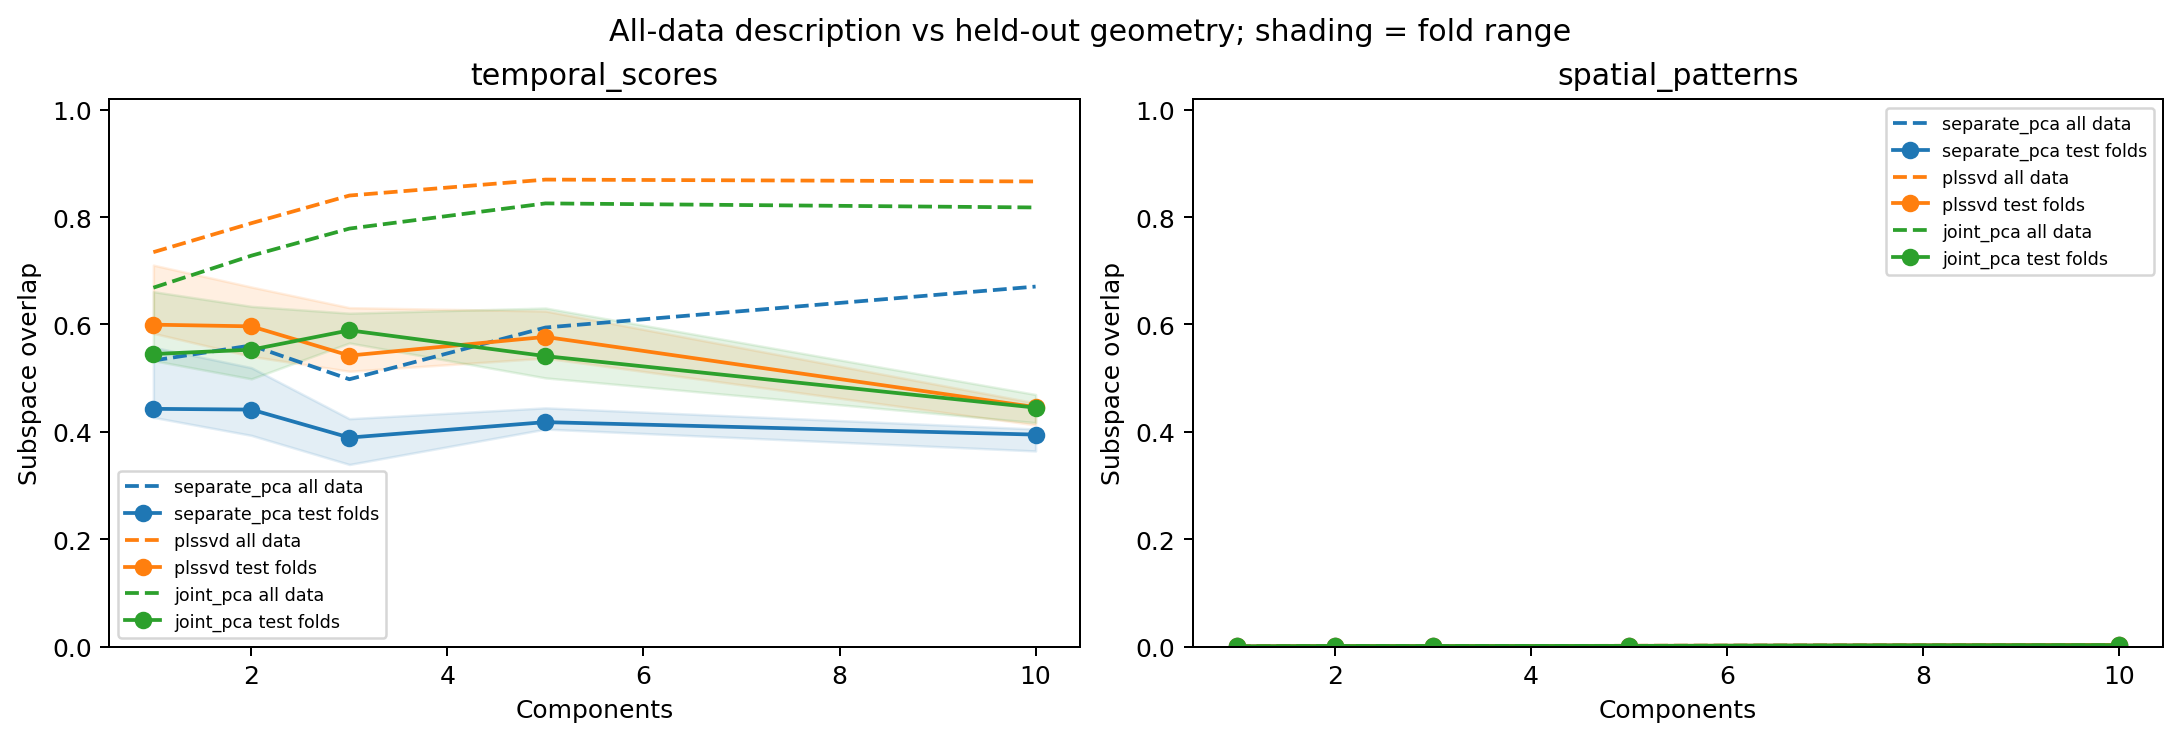

,model,repeat,space,k,overlap,rank_a,rank_b,angles_deg
30,separate_pca,0,temporal_scores,1,0.557556,1,1,[41.69494355504188]
32,separate_pca,0,spatial_patterns,1,0.000119,1,1,[89.3762773614969]
34,separate_pca,0,temporal_scores,2,0.510401,2,2,"[41.68496019633413, 47.11771406705361]"
36,separate_pca,0,spatial_patterns,2,0.000414,2,2,"[88.49859700827174, 89.31737155891281]"
38,separate_pca,0,temporal_scores,3,0.424379,3,3,"[27.841803613968555, 46.919979384499136, 80.95..."
...,...,...,...,...,...,...,...,...
320,joint_pca,4,spatial_patterns,3,0.000474,3,3,"[88.07196352198834, 89.11924407377195, 89.5791..."
322,joint_pca,4,temporal_scores,5,0.575597,5,5,"[25.69463570805392, 31.542166166067283, 42.825..."
324,joint_pca,4,spatial_patterns,5,0.001118,5,5,"[86.76654333897342, 87.6816332110351, 88.57558..."
326,joint_pca,4,temporal_scores,10,0.463372,10,10,"[21.07012559565514, 26.41231820741519, 36.8374..."


In [3]:
display(Image(filename=str(OUTPUT_DIR / 'subspace_overlap.png')))
display(tables['overlap'].query("partition == 'test'")[
    ['model', 'repeat', 'space', 'k', 'overlap', 'rank_a', 'rank_b', 'angles_deg']])


## 2. Transformation generalization
Training means and one scalar RMS normalize each modality's representation. Fit identity, orthogonal, affine and quadratic maps in both directions. Ridge is fixed beforehand (default 0.01); no tuning. Apply each map unchanged to held-out responses.

NRMSE below 1 beats the training-mean baseline; Q² = 1 − NRMSE². Dashed all-data results are descriptive; use test-fold errors to assess generalization. Time points and locations recur across partitions.


- Identity	Nothing beyond the preceding training-based centering and overall scaling
- Orthogonal	Component signs, order, rotation and reflection; preserves distances
- Affine	Also allows unequal scaling and general linear mixing
- Quadratic	Adds squared coordinates and interactions between coordinates

| Error | Interpretation |
|---|---|
| \(0\) | Perfect prediction |
| \(0.7\) | Squared prediction error is 49% of the baseline error; \(Q^2=0.51\) |
| \(1\) | No improvement over predicting the target’s training mean |
| \(>1\) | Worse than predicting that mean |

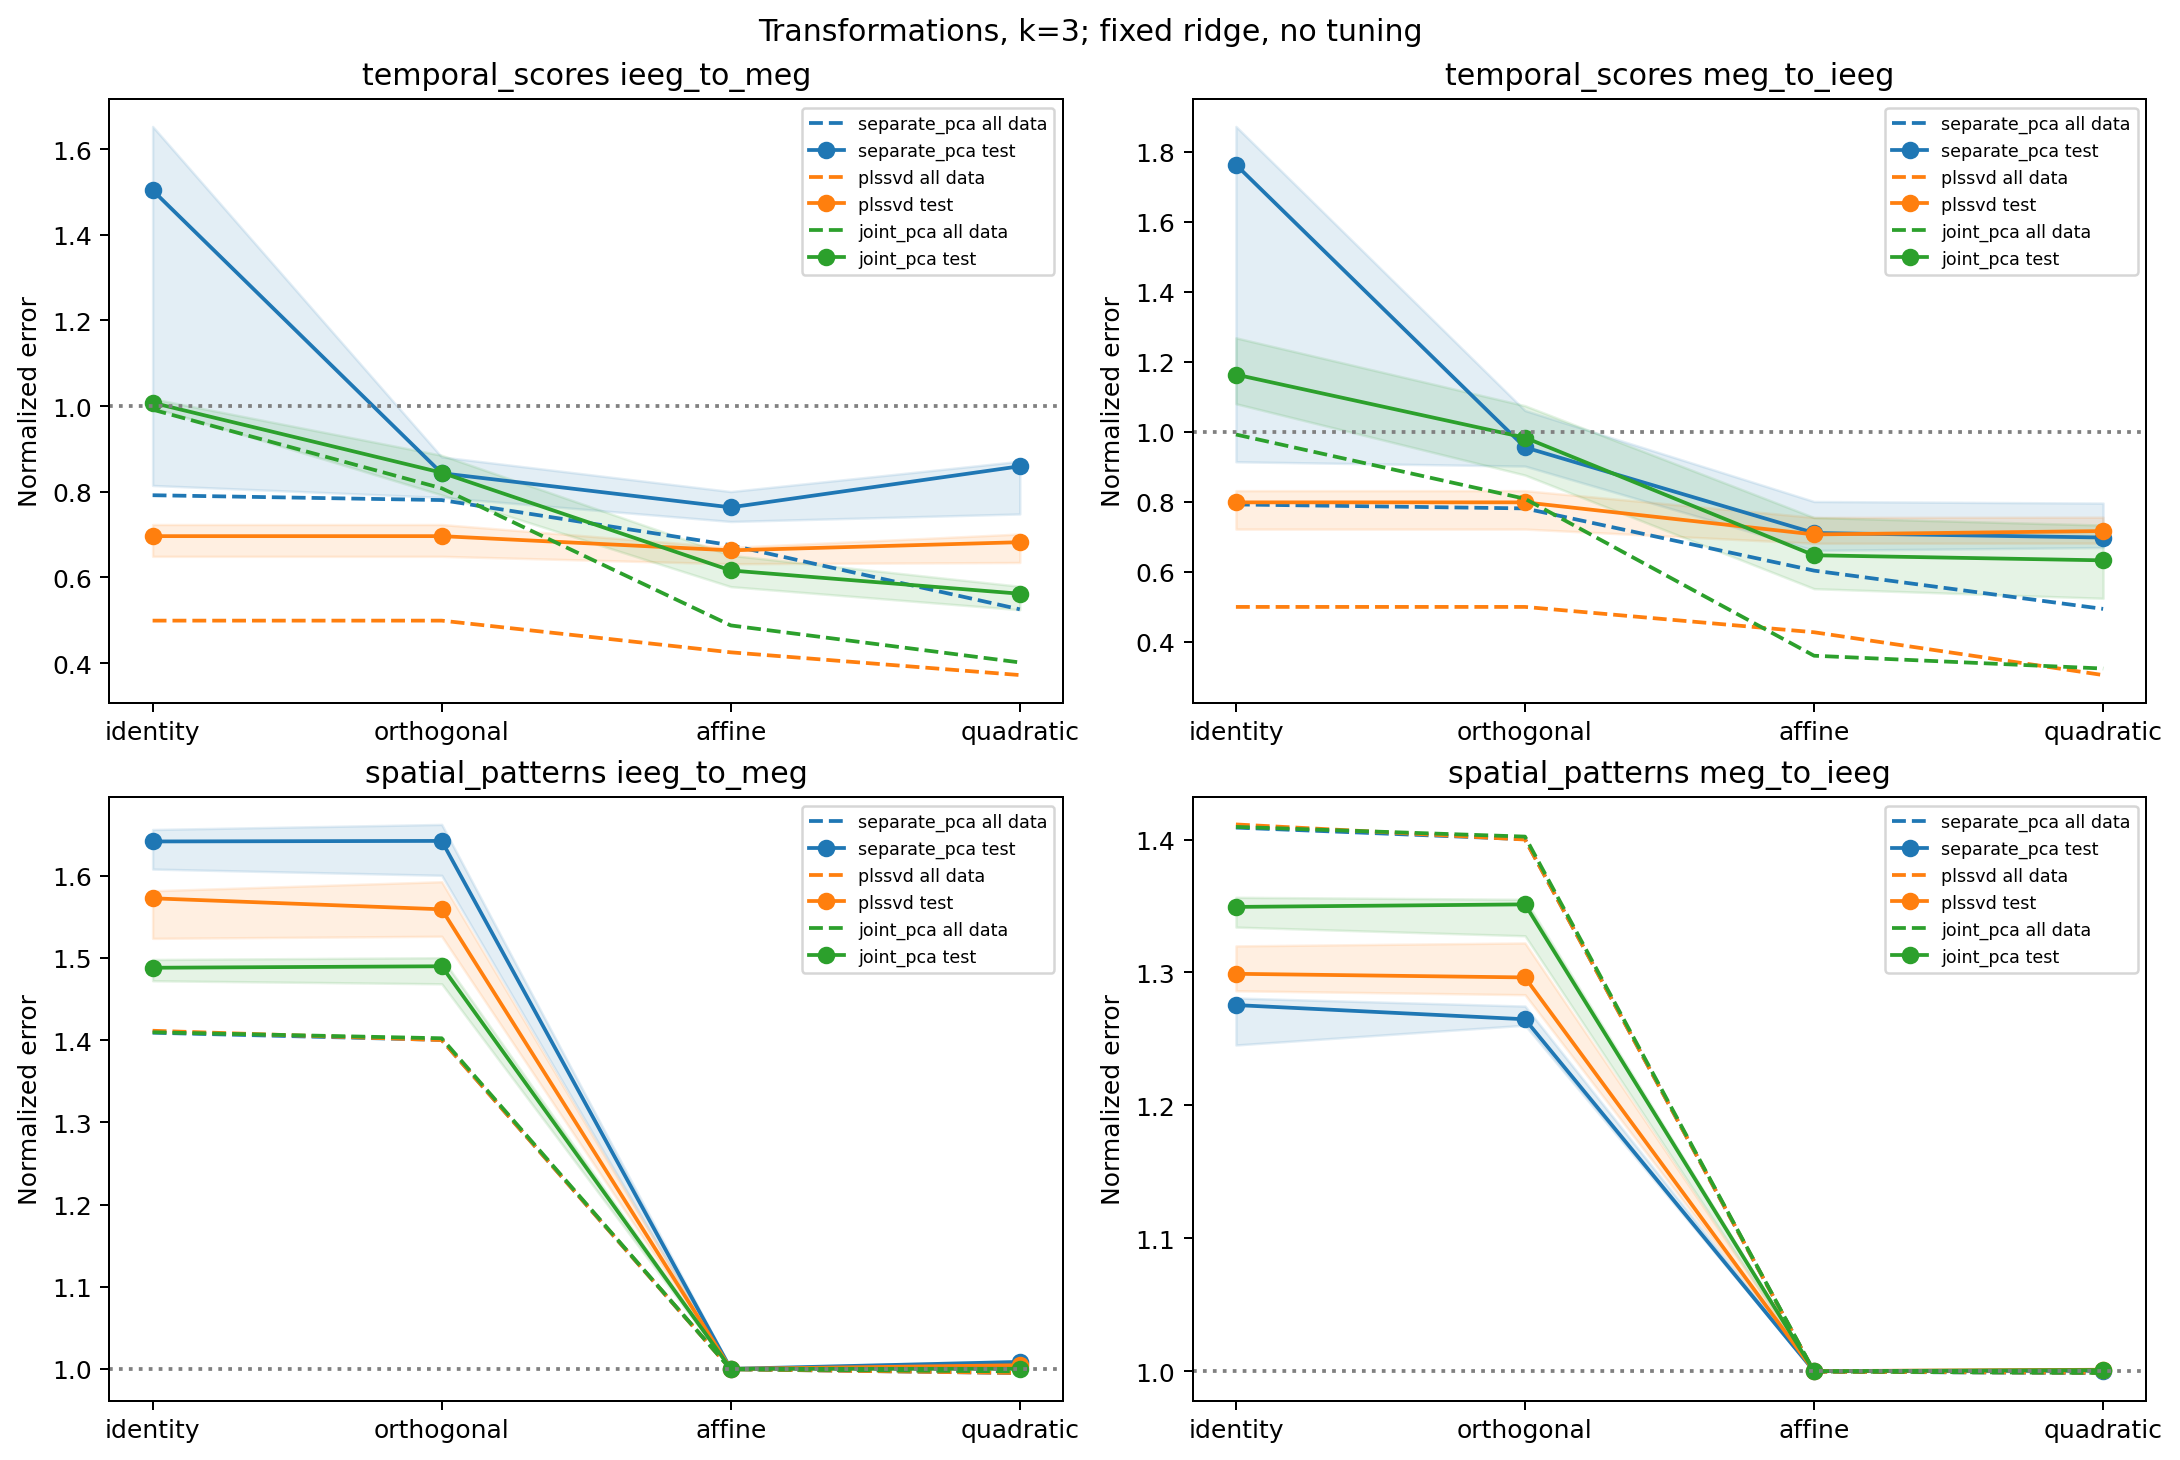

,model,repeat,space,direction,complexity,alpha,nrmse,q2
304,separate_pca,0,temporal_scores,ieeg_to_meg,identity,0.00,1.503724,-1.261187
306,separate_pca,0,temporal_scores,ieeg_to_meg,orthogonal,0.00,0.786817,0.380919
308,separate_pca,0,temporal_scores,ieeg_to_meg,affine,0.01,0.730504,0.466364
310,separate_pca,0,temporal_scores,ieeg_to_meg,quadratic,0.01,0.748090,0.440361
312,separate_pca,0,temporal_scores,meg_to_ieeg,identity,0.00,1.730029,-1.992999
...,...,...,...,...,...,...,...,...
2566,joint_pca,4,spatial_patterns,ieeg_to_meg,quadratic,0.01,1.000205,-0.000411
2568,joint_pca,4,spatial_patterns,meg_to_ieeg,identity,0.00,1.349317,-0.820656
2570,joint_pca,4,spatial_patterns,meg_to_ieeg,orthogonal,0.00,1.355021,-0.836082
2572,joint_pca,4,spatial_patterns,meg_to_ieeg,affine,0.01,1.000197,-0.000395


In [4]:
display(Image(filename=str(OUTPUT_DIR / f'alignment_complexity_k{DISPLAY_K}.png')))
display(tables['alignment'].query("partition == 'test' and k == @DISPLAY_K")[
    ['model', 'repeat', 'space', 'direction', 'complexity', 'alpha', 'nrmse', 'q2']])


## 3. Fold consistency
Test folds do not overlap. Training folds do overlap, so the range across test scores is descriptive, not independent replication. There are no A/B reliability outputs.


In [9]:
display(tables['alignment'].query("partition == 'test' and k == @DISPLAY_K").groupby(
    ['model', 'space', 'direction', 'complexity'])[['nrmse', 'q2']].agg(['median', 'min', 'max']))

# TODO : FIG

nrmse            \
                                                        median       min   
model        space            direction   complexity                       
joint_pca    spatial_patterns ieeg_to_meg affine      1.000196  0.999797   
                                          identity    1.487993  1.472192   
                                          orthogonal  1.489798  1.468458   
                                          quadratic   1.000205  0.999758   
                              meg_to_ieeg affine      1.000039  0.999950   
                                          identity    1.349317  1.334133   
                                          orthogonal  1.351231  1.327607   
                                          quadratic   1.000869  1.000028   
             temporal_scores  ieeg_to_meg affine      0.616222  0.578394   
                                          identity    1.007642  0.996877   
                                          orthogonal  0.844445  0.792502   
                                          quadratic   0.561931  0.524516   
                              meg_to_ieeg affine      0.646631  0.551194   
                                          identity    1.162830  1.079506   
                                          orthogonal  0.982772  0.875720   
                                          quadratic   0.632132  0.523731   
plssvd       spatial_patterns ieeg_to_meg affine      1.000104  0.999838   
                                          identity    1.572474  1.523744   
                                          orthogonal  1.559078  1.526305   
                                          quadratic   1.004593  1.001829   
                              meg_to_ieeg affine      1.000074  0.999885   
                                          identity    1.299009  1.286219   
                                          orthogonal  1.296262  1.283265   
                                          quadratic   1.001121  1.000265   
             temporal_scores  ieeg_to_meg affine      0.663175  0.631807   
                                          identity    0.696309  0.649180   
                                          orthogonal  0.696309  0.649180   
                                          quadratic   0.682185  0.634788   
                              meg_to_ieeg affine      0.706121  0.680835   
                                          identity    0.797804  0.721466   
                                          orthogonal  0.797804  0.721466   
                                          quadratic   0.715793  0.681283   
separate_pca spatial_patterns ieeg_to_meg affine      1.000174  0.999917   
                                          identity    1.641607  1.608037   
                                          orthogonal  1.642269  1.600430   
                                          quadratic   1.008568  1.003318   
                              meg_to_ieeg affine      1.000050  0.999924   
                                          identity    1.275475  1.245449   
                                          orthogonal  1.264798  1.260298   
                                          quadratic   1.000449  0.999692   
             temporal_scores  ieeg_to_meg affine      0.763524  0.730504   
                                          identity    1.503724  0.814615   
                                          orthogonal  0.843173  0.786817   
                                          quadratic   0.859370  0.748090   
                              meg_to_ieeg affine      0.710383  0.660663   
                                          identity    1.762335  0.913756   
                                          orthogonal  0.954901  0.901332   
                                          quadratic   0.697328  0.668808   

                                                                      q2  \
                                                           max    median   
model        space          

## 4. Exploratory spatial grouping
K-means is fitted separately to each modality's training spatial patterns. All predeclared cluster counts are reported; none is selected using test agreement. Held-out patterns are assigned to training centroids. ARI compares cross-modal membership and silhouette describes compactness/separation. No test-half stability is computed. Stable groups do not by themselves establish biological networks.

ARI essentially asks whether pairs of locations are grouped together or separated consistently between modalities, with a correction for chance agreement.
- 1: identical partitions.
- Around 0: agreement near the chance-adjusted reference.
- Negative: less agreement than that reference.


Pairwise cluster.

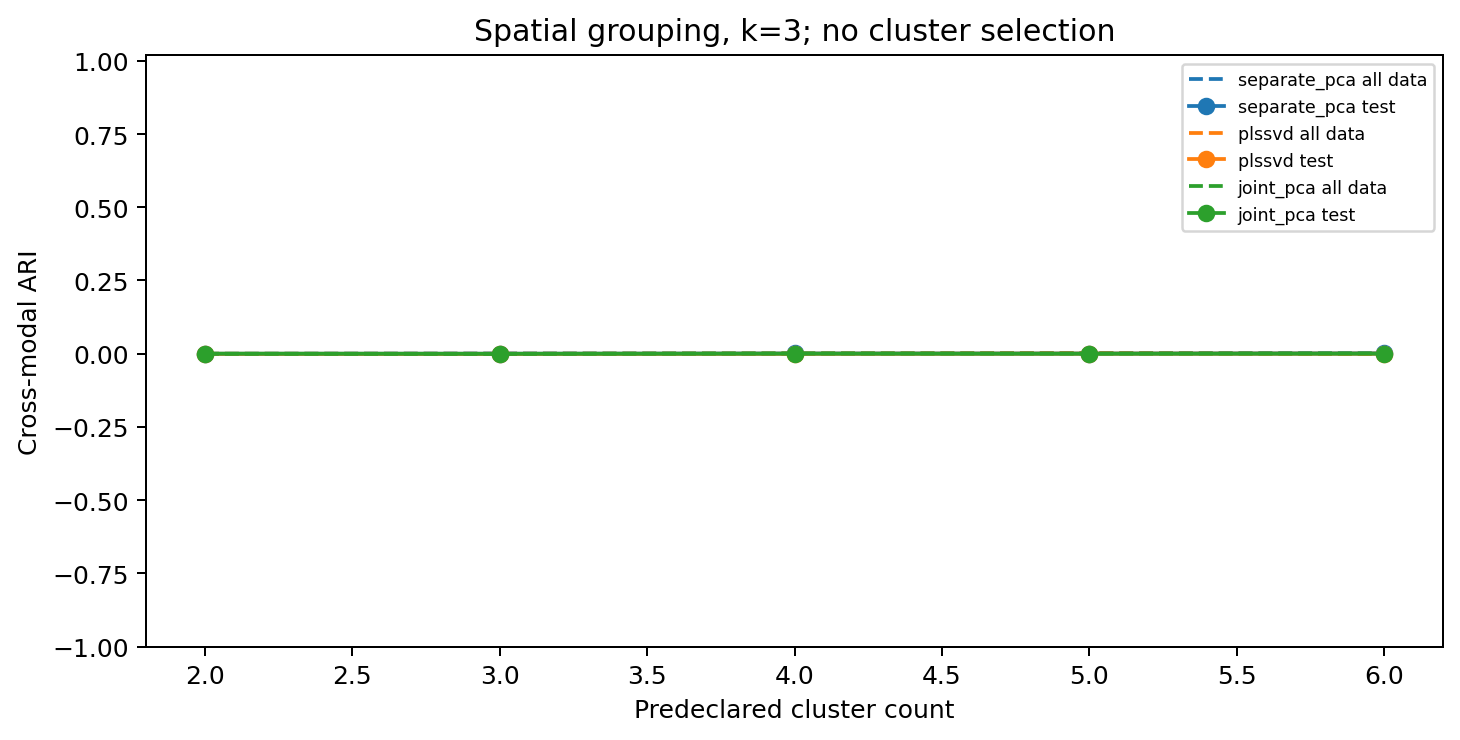

,analysis,model,repeat,k,metric,modality,partition,value,n_clusters
285,cross_validation,separate_pca,0,3,cross_modal_ari,both,test,-0.000300,2
286,cross_validation,separate_pca,0,3,silhouette,ieeg,test,0.185939,2
287,cross_validation,separate_pca,0,3,silhouette,meg,test,0.201372,2
291,cross_validation,separate_pca,0,3,cross_modal_ari,both,test,-0.000110,3
292,cross_validation,separate_pca,0,3,silhouette,ieeg,test,0.221499,3
...,...,...,...,...,...,...,...,...,...
2404,cross_validation,joint_pca,4,3,silhouette,ieeg,test,0.186268,5
2405,cross_validation,joint_pca,4,3,silhouette,meg,test,0.251727,5
2409,cross_validation,joint_pca,4,3,cross_modal_ari,both,test,-0.000708,6
2410,cross_validation,joint_pca,4,3,silhouette,ieeg,test,0.190980,6


In [6]:
display(Image(filename=str(OUTPUT_DIR / f'cluster_agreement_k{DISPLAY_K}.png')))
display(tables['clusters'].query("partition == 'test' and k == @DISPLAY_K"))


## Full-data 3D component-space clusters
For each model, view two side-by-side iEEG/MEG figures: (1) choose the highest full-data silhouette separately in each modality; (2) choose the common count with highest full-data cross-modal ARI. Both are descriptive choices among the saved candidate counts, with ties favoring fewer clusters. ARI compares separate clusterings; no joint K-means is fitted.
Points are electrodes/mapped sources represented by their three spatial forward-pattern coefficients, centered and uniformly scaled using the saved training normalization. Brain x/y/z are not used. X marks centroids. The ARI view matches cluster colours by membership agreement. Same colours need not mean identical membership, and component axes have not been aligned across modalities.
Requires full-data k=3 artifacts from the completed analysis; no refitting is needed. Exports PNG/PDF and a descriptive selection table under `full_data_clusters_3d/`.


In [ ]:
from compare_subspace import plot_full_data_clusters
cluster_paths, cluster_choices = plot_full_data_clusters(OUTPUT_DIR, show=True)
display(cluster_choices)
